# Imports and loading data

In [ ]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf
from keras import layers
from sklearn.model_selection import train_test_split

In [ ]:
from pathlib import Path
import os

def find_repo_root(start=None):
    start = Path(start or os.getcwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing data/raw/")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Repo root:", REPO_ROOT)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

In [ ]:
train_df = pd.read_csv(TRAIN_PATH).rename(columns={
    'Class Index': 'class',
    'Title': 'title',
    'Description': 'description'
})

In [ ]:
test_df = pd.read_csv(TEST_PATH).rename(
    columns={
        'Class Index': 'class',
        'Title': 'title',
        'Description': 'description'
    }
)

In [ ]:
# combining title and description, as it's been identified as strongest predictor combo
train_df['all_text'] = train_df['title'] + ' ' + train_df['description']

In [ ]:
train_df.head()

,class,title,description,all_text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [ ]:
test_df['all_text'] = test_df['title'] + ' ' + test_df['description']

In [ ]:
# converting labels from {1,..,4} to {0, ..., 3} to match loss expectation
y_train = train_df['class'] - 1

In [ ]:
y_train = y_train.values

In [ ]:
y_test = test_df['class'].values - 1

In [ ]:
X_train = train_df.all_text.values

In [ ]:
X_test = test_df.all_text.values

# Simple Stratified Train_Test_Split for first Run

GOAL: ensure RNN works on this data

In [ ]:
BATCH_SIZE = 128

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=1, stratify=y_train
)


In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_tr, y_tr) # converts arrays into tf data where each row becomes a tuples (x, y) pair so model consumes iterable batches
).batch(BATCH_SIZE # tuple with 2 arrays, each of BATCH SIZE to stabilize gradient updates and improve training speed
        ).prefetch(tf.data.AUTOTUNE) # allows GPU to train while tf prepares next batch in background

In [ ]:
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Tokenization

In [ ]:
MAX_TOKENS = 30000 # vocab cap size. regularization + efficiency control (e.g., don't make embeddings for rare words)
MAX_LEN = 200 # sequence length cap

MAX_LEN set so every token embedding is of length 200 (can't have embeddings of different shape)
 - short text is padded with zeros
 - long text truncated

Essentially a generalization decision. News topics often reveal strong signal early. Long tail text descriptions provide diminishing returns (little signal) after a certain point


In [ ]:
text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int', # produces sequence of token IDs
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation',
    split='whitespace'
)

In [ ]:
train_text = train_dataset.map(lambda x, y: x) # keeps only text batch for tokenization

In [ ]:
text_vectorizer.adapt(train_text) # prevents data leakage. Ensures vocabulary is learned from training data only

**TextVectorization.adapt() learns statistics from text:

1. Splits text into tokens (splits at whitespace)
2. Removes punctuation and lower cases characters (normalization)
3. Counts token frequencies
4. Ranks token freqiencies
5. Assigns (int) IDs to each token (descending order)
6. Keeps top MAX_TOKENS - 1

Adapt() ensures only training data is seen by text_vectorizer (freezes vocab)

This mapping is then applied to validation and test data using its established rules and findings on training data


## Converting datasets into integer token sequences

In [ ]:
# converts raw strings to integer sequences (fixed-length numericntensors)
def vectorize_batch(text, label):
  token_ids = text_vectorizer(text)
  return token_ids, label # tokens_id.shape == (batch_size, MAX_LEN)

If text_vectorizer("Oil prices surge today"), then what is returns is an array of (potentially) --> [ 417, 892. 1432, 78, 0, 0, ..., n] where n == MAX_LEN.

function essentially does "replace raw text with token IDs, but keep same label pairings."

### Mapping function over the datasets

In [ ]:
train_seq_dataset = train_dataset.map( # map appies function to every element in dataset
    vectorize_batch, # (text batch, label batch) becomes (token_id_batch, label_batch)
    num_parallel_calls=tf.data.AUTOTUNE) # enables vectorize_batch to apply to multiple batches in parallel, using as many CPU threads as possible (dynamilly adjusts during runtime))

In [ ]:
val_seq_dataset = val_dataset.map(vectorize_batch,
                                  num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
test_seq_data = test_dataset.map(vectorize_batch,
                                 num_parallel_calls=tf.data.AUTOTUNE)

# Building RNN Model (LSTM)


In [ ]:
def build_rnn_model(
    # what model allowed to see
    max_tokens=MAX_TOKENS, # size of vocab == number of embeddings learned (global)
    max_len=MAX_LEN, # number of tokens per input sequence i.e., how many time steps. each step performs matrix multiplications and backpropagation (local/per article aka how much model is allowed to see of each individual article)
    # how model processes info
    embed_dim=128, # dimensionality of each work vector. Good balance for gathering token semantic info and nuanced relations
    rnn_units=128, # size of LSTM's hidden state (summarizes each example into a vector of length 128)
    rnn_type='lstm',
    bidirectional=False, # lstm only reads left to right (uncessecsary because news topics and early words already provide strong signal for classification)
    # how model learns
    dropout=0.5, # proportion of features randomly zeroed during training
    lr=1e-3 # step size of gradient updates
):
  inputs = keras.Input(shape=(max_len,), dtype='int32') # 1D vector of len max_len, where each value is a token ID. simply a SYMBOLIC tensor.
  # inputs: (batch_size, max_len)

  x = layers.Embedding( # converts token IDs to dense vectors
      input_dim=max_tokens, # number of rows in the embedding matrix
      output_dim=embed_dim, # length of each embedding vector
      mask_zero=True # zeros are ignored as token IDs so these IDs aren't assigned embeddings
  )(inputs) # (inputs) connects embedding layer to inputs
  # after embedding: (batch_size, max_len, embed_dim)

  rnn_layer = layers.LSTM(rnn_units) if rnn_type=='lstm' else layers.GRU(rnn_units) # reads sequence step-by-step and outputs a learned representation of whole sequence
  # lstm compresses entire text into a single vector of length rnn_units that is fed into classifier head
  # shape changes to: (batch_size, rnn_units)
  x = layers.Bidirectional(rnn_layer)(x) if bidirectional else rnn_layer(x)
 # bidirectional will run one LSTM forward, one backward and then concatenates outputs (likely not necessary)
  x = layers.Dropout(dropout)(x)

  outputs = layers.Dense(4, activation='softmax')(x) # model outputs (batch_size, 4) of probability values for

  model = keras.Model(inputs, outputs)
  # binds together the input and computed output tensor into tranable keras model

  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'],
  )

  return model

 - **Embedding matrix shape** = (max_tokens, embed_dim) <-- is set before LSTM starts
 - **embed_dim** turns (batch size, max_len) into (batch, max_len, embed_dim)
 - **rnn_units** compresses 200 tokens in an article into one vector for multinomial classification. This is enough to encode topic structure and small enough for fast CV
 - **lstm** has input, forget, and output gates. Plus a memory cell. Provides stronger long-term memory, more parameters and more stable gradients (relative to 'gru'). Slightly slower speed

## Training with Early Stopping

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', # watches validation loss after each epoch
    patience=2, # training stops if val_loss fails to improve for 2 consecutive epochs
    restore_best_weights=True # rolls model back to epoch with lowest val_loss (keeps these weights)
)

### building model

In [ ]:
model = build_rnn_model()

In [ ]:
history = model.fit(train_seq_dataset, # (token_id_batch, label_batch). Computes forward pass, loss, backpropagation of gradients and weight updates
          validation_data=val_seq_dataset,
          epochs=10, # model can train for (up to) 10 passes over the full training data
          callbacks=[early_stopping],) # early stopping checked after each epoch

# history contains a dictionary-like object storing per-epoch metrics
# history.history.keys() (loss, accuracy, val_loss, val_accuracy)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 731s 861ms/step - accuracy: 0.7874 - loss: 0.5462 - val_accuracy: 0.9169 - val_loss: 0.2641
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 670s 775ms/step - accuracy: 0.9307 - loss: 0.2231 - val_accuracy: 0.9140 - val_loss: 0.2750
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 675s 800ms/step - accuracy: 0.9473 - loss: 0.1666 - val_accuracy: 0.9088 - val_loss: 0.2937


### Plotting Learning Curves

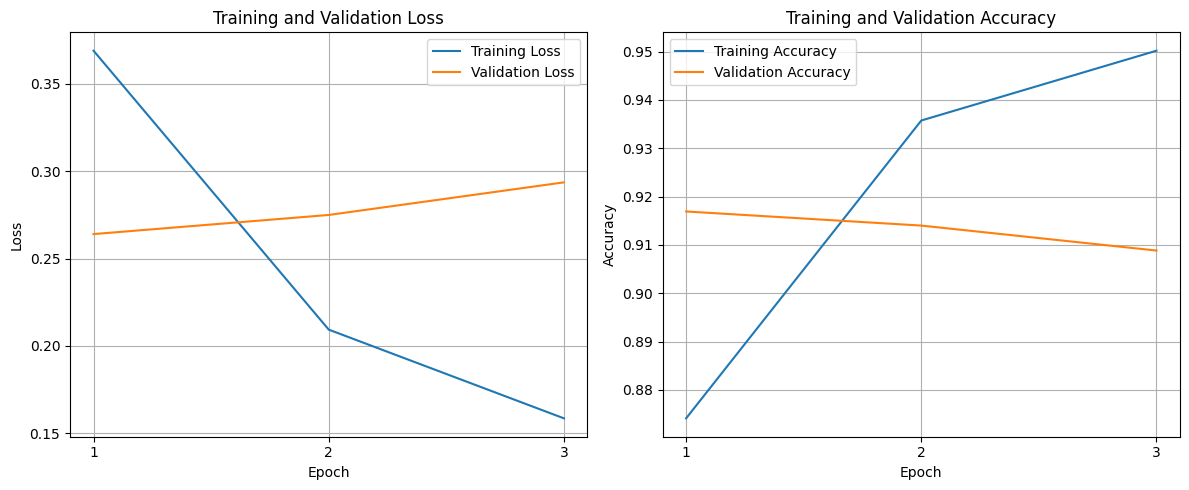

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.xticks(np.arange(min(epochs), max(epochs)+1, 1)) # Set x-ticks to integers
    plt.legend()
    plt.grid(True)

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.xticks(np.arange(min(epochs), max(epochs)+1, 1)) # Set x-ticks to integers
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

No instability, variance explosion or nsight of sentitivity to random initialization. Model already generalizes well and validation performance doesn't improve with additional training.

^ reasons to SKIP OVER DOING GRIDSEARCH CV

Sequential modeling does NOT substantially outperform bag-of-words for this task.